# Measurements of Quantum States

In [2]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from numpy import sqrt

Measuring an entire combined state at once (i.e. measuring both qubits in a two-qubit system) is quite straightforward, the measurement outcomes of each qubit are the squares of the coefficients of the state vector.

For example, if we measure the below state vector:
$$|\psi\rangle = \frac{3}{5}|00\rangle - \frac{4i}{\sqrt{5}}|11\rangle$$

We will measure the state $|00\rangle$ with probability $\frac{9}{25}$ and the state $|11\rangle$ with probability $\frac{16}{25}$.

<IPython.core.display.Latex object>

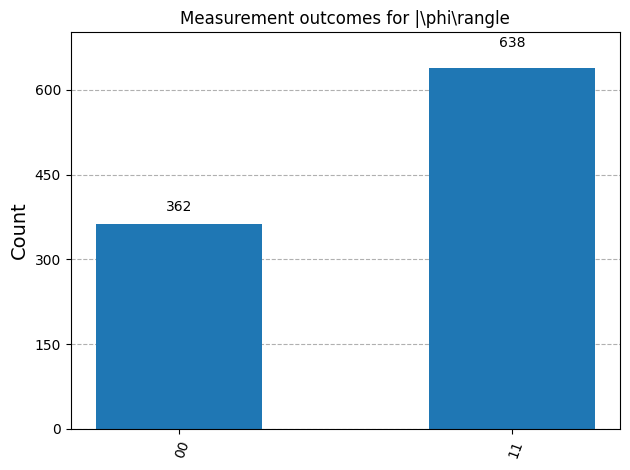

In [3]:
c00 = 3 / 5
c11 = -4j / (5)

psi = Statevector([c00, 0, 0, c11])
display(psi.draw('latex', prefix="|\\psi\\rangle = "))

display(plot_histogram(data=psi.sample_counts(1000), title="Measurement outcomes for |\\phi\\rangle"))


However, partial measurements (i.e. measuring only one qubit in a multi-qubit system) are more complex. For example, when we measure 1 qubit in a 2-qubit system, we "collapse" the combined state into a new state that is consistent with the measurement outcome.

Consider $\psi$ below:
$$|\psi\rangle = \frac{1}{\sqrt{2}}|00\rangle - \frac{1}{\sqrt{6}}|01\rangle + \frac{i}{\sqrt{6}}|10\rangle + \frac{1}{\sqrt{6}}|11\rangle$$

To visually separate the first qubit out of this system, we can write the state as:
$$|\psi\rangle = |0\rangle \otimes \left(\frac{1}{\sqrt{2}}|0\rangle - \frac{1}{\sqrt{6}}|1\rangle\right) + |1\rangle \otimes \left(\frac{i}{\sqrt{6}}|0\rangle + \frac{1}{\sqrt{6}}|1\rangle\right)$$

Now it is obvious that the probability of measuring 0 for the first qubit is:
$$\left\|\frac{1}{\sqrt{2}}|0\rangle - \frac{1}{\sqrt{6}}|1\rangle\right\|^2 = \frac{1}{2} + \frac{1}{6} = \frac{2}{3}$$

If we measure 0, the new state becomes (proof found in [IBM section](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/multiple-systems/quantum-information#partial-measurements)):
$$|0\rangle \otimes \frac{\frac{1}{\sqrt{2}}|0\rangle - \frac{1}{\sqrt{6}}|1\rangle}{\sqrt{\frac{2}{3}}} = |0\rangle \otimes \left(\frac{\sqrt{3}}{2}|0\rangle - \frac{1}{2}|1\rangle\right) = \frac{\sqrt{3}}{2}|00\rangle - \frac{1}{2}|01\rangle$$


<IPython.core.display.Latex object>

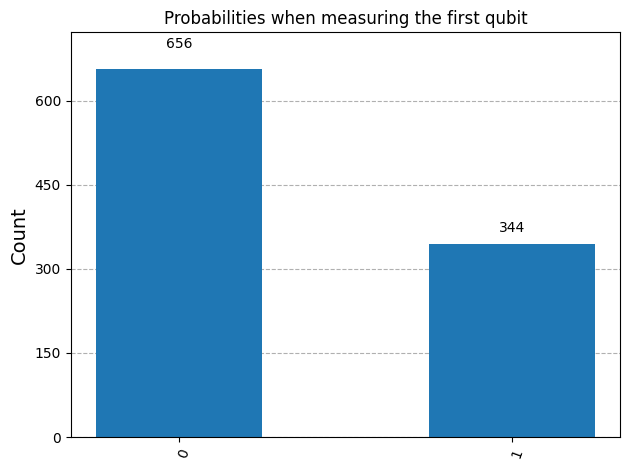

Measurement result: 0


<IPython.core.display.Latex object>

In [19]:
psi = Statevector([1/sqrt(2), -1/sqrt(6), 1j/sqrt(6), 1/sqrt(6)])
display(psi.draw('latex', prefix="|\\psi\\rangle = "))

# probability when measuring just the first qubit
# note that in qiskit, the leftmost qubit is the second qubit in qargs
# so in a 2 qubit system [0, 1], we want to measure 1
# if you want the measure the second qubit change qargs to [0]
display(plot_histogram(
    data=psi.sample_counts(1000, qargs=[1]), 
    title="Probabilities when measuring the first qubit"
))

result, state = psi.measure(qargs=[1])
print(f"Measurement result: {result}")
display(state.draw('latex', prefix="State after measurement: "))